<img style="float: middle;" src="../images/logo.png">

# Module 004 &mdash; Deep Learning 04

# A Vision Transformer (ViT) for H&E spatial data

Notebook `03` treated a spot as a *sentence of genes*. Here we keep the Transformer
idea but switch modality to the **H&E histology image**, using a
**[Vision Transformer](https://arxiv.org/abs/2010.11929)**.

The change of perspective for images is:

> **An image tile is a grid of small patches, and each patch is a "token".**

A ViT cuts the tile into patches, embeds each one, and lets self-attention mix
information across patches. We will use it for an idea popularised by
**[ST-Net](https://www.nature.com/articles/s41551-020-0578-x)** /
**[HE2RNA](https://www.nature.com/articles/s41467-020-17678-4)**:

> **Predict gene expression directly from morphology** &mdash; image &rarr; expression.

For each Visium spot we crop the H&E tile under it and train a ViT to regress the
expression of a panel of **marker genes**. Same `Visium_Skin_A2` sample as notebook 03.

## 0. Setup

In [1]:
import warnings, json
from pathlib import Path
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
from PIL import Image
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from scipy.stats import pearsonr

warnings.filterwarnings("ignore")
sc.settings.verbosity = 0

SEED = 0
np.random.seed(SEED); torch.manual_seed(SEED)
torch.set_num_threads(4)
device = "cpu"
print("torch", torch.__version__, "| device:", device)

# ---> Point this at your copy of the Visium sample <---
DATA_DIR = Path("/QRISdata/Q1851/Xiao/winter_school_data_2025/Visium_Skin_A2/outs")

/home/uqxtan9/micromamba/envs/FSTimage/lib/python3.11/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


torch 2.9.1+cu128 | device: cpu


## 1. Load expression, the H&E image, and spot positions

We need three things from the Space Ranger output:

* `filtered_feature_bc_matrix.h5` &mdash; the gene expression (our prediction *target*),
* `spatial/tissue_hires_image.png` &mdash; the H&E image (our *input*),
* `spatial/tissue_positions.csv` + `scalefactors_json.json` &mdash; where each spot sits in
  the image. Positions are in **full-resolution** pixels, so we multiply by
  `tissue_hires_scalef` to map them onto the hi-res image.

In [2]:
adata = sc.read_10x_h5(DATA_DIR / "filtered_feature_bc_matrix.h5")
adata.var_names_make_unique()
sc.pp.filter_genes(adata, min_cells=10)
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

sf = json.load(open(DATA_DIR / "spatial/scalefactors_json.json"))
hires_scalef = sf["tissue_hires_scalef"]
pos = pd.read_csv(DATA_DIR / "spatial/tissue_positions.csv")
pos = pos[pos.in_tissue == 1].set_index("barcode")
common = [b for b in adata.obs_names if b in pos.index]
adata = adata[common].copy(); pos = pos.loc[common]

img = np.asarray(Image.open(DATA_DIR / "spatial/tissue_hires_image.png").convert("RGB"))
row_h = (pos.pxl_row_in_fullres.values * hires_scalef).astype(int)   # y in hi-res px
col_h = (pos.pxl_col_in_fullres.values * hires_scalef).astype(int)   # x in hi-res px
print("H&E image:", img.shape, "| spots:", adata.n_obs)

H&E image: (1942, 2000, 3) | spots: 2302


## 2. Extract an H&E tile per spot

We crop a small window centred on each spot and resize it to `64 x 64`. We read the
image into memory **once** and crop from the array (never re-read the file per spot).
The image is padded at the border so spots near the edge still yield a full tile.

In [3]:
WIN = 40          # crop window in hi-res pixels (spot diameter is ~19 px here)
OUT = 64          # tile size fed to the ViT
imgp = np.pad(img, ((WIN, WIN), (WIN, WIN), (0, 0)), mode="edge")
tiles = np.zeros((adata.n_obs, OUT, OUT, 3), dtype=np.float32)
for i, (r, c) in enumerate(zip(row_h, col_h)):
    r0, c0 = r + WIN - WIN // 2, c + WIN - WIN // 2     # +WIN for the padding offset
    crop = imgp[r0:r0 + WIN, c0:c0 + WIN]
    tiles[i] = np.asarray(Image.fromarray(crop).resize((OUT, OUT), Image.BILINEAR)) / 255.0
print("tiles:", tiles.shape)

tiles: (2302, 64, 64, 3)


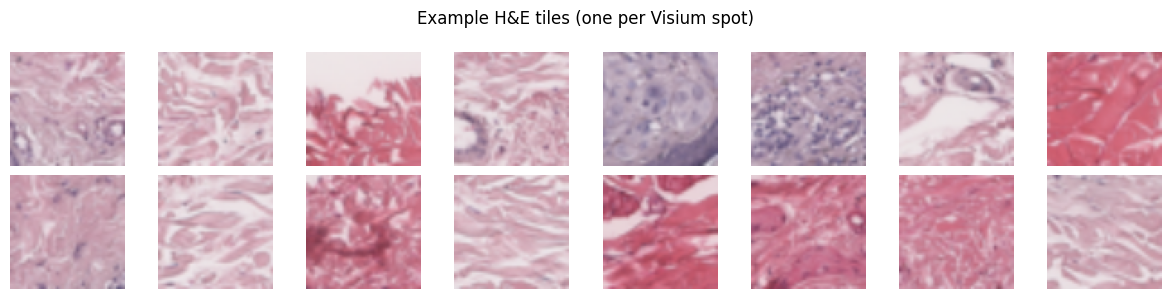

In [4]:
# A few example tiles
fig, axes = plt.subplots(2, 8, figsize=(12, 3))
for ax, i in zip(axes.ravel(), np.random.choice(adata.n_obs, 16, replace=False)):
    ax.imshow(tiles[i]); ax.axis("off")
fig.suptitle("Example H&E tiles (one per Visium spot)"); plt.tight_layout(); plt.show()

## 3. Choose the marker genes to predict

We predict a panel of interpretable markers (keratins for epidermis, collagens/`DCN`/`LUM`
for dermis, `MLANA`/`PMEL`/`TYRP1` for melanocytes, `CD3D`/`PTPRC` for immune cells),
topped up with highly-variable genes to 16 targets. Targets are the `log1p`-normalised
expression, **standardised per gene** (z-score) so the regression treats genes evenly.

In [5]:
markers = ["KRT14", "KRT5", "KRT10", "KRT1", "COL1A1", "COL1A2", "COL3A1",
           "DCN", "LUM", "MLANA", "PMEL", "TYRP1", "CD3D", "CD3E", "PTPRC", "MGP"]
present = [g for g in markers if g in adata.var_names]
sc.pp.highly_variable_genes(adata, n_top_genes=2000)
for g in adata.var.sort_values("dispersions_norm", ascending=False).index:
    if len(present) >= 16:
        break
    if g not in present:
        present.append(g)
present = present[:16]
print("target genes:", present)

Yexpr = adata[:, present].X
Yexpr = np.asarray(Yexpr.todense()) if hasattr(Yexpr, "todense") else np.asarray(Yexpr)
ymean, ystd = Yexpr.mean(0), Yexpr.std(0) + 1e-8
Yz = (Yexpr - ymean) / ystd

target genes: ['KRT14', 'KRT5', 'KRT10', 'KRT1', 'COL1A1', 'COL1A2', 'COL3A1', 'DCN', 'LUM', 'MLANA', 'PMEL', 'TYRP1', 'CD3D', 'CD3E', 'PTPRC', 'MGP']


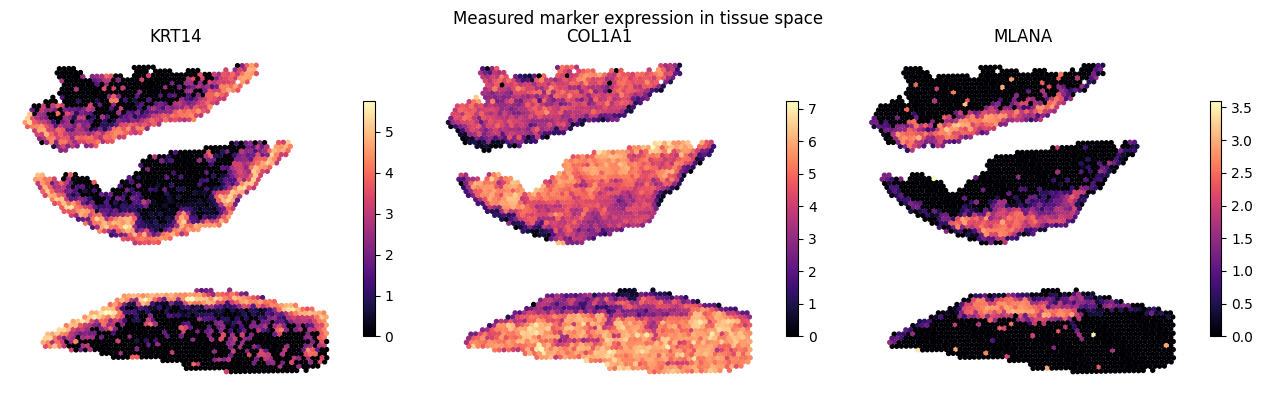

In [6]:
# What does the spatial pattern of a couple of markers look like?
xy = np.c_[col_h, row_h]
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, g in zip(axes, ["KRT14", "COL1A1", "MLANA"]):
    j = present.index(g)
    sca = ax.scatter(xy[:, 0], -xy[:, 1], c=Yexpr[:, j], cmap="magma", s=8)
    ax.set_aspect("equal"); ax.axis("off"); ax.set_title(g); plt.colorbar(sca, ax=ax, shrink=0.7)
plt.suptitle("Measured marker expression in tissue space"); plt.tight_layout(); plt.show()

## 4. Build the Vision Transformer (from scratch)

The only new piece compared with notebook 03 is **patch embedding**: a strided
convolution slices the `64 x 64` tile into `8 x 8` patches and projects each to a vector,
giving `8 x 8 = 64` patch tokens. We then prepend a `[CLS]` token, add a learnable
**positional embedding** (so the model knows where each patch sat), and reuse the **exact
same `TransformerBlock`** from the gene notebook. The `[CLS]` output feeds a linear
**regression** head predicting the 16 markers.

In [7]:
class TransformerBlock(nn.Module):
    """Identical block to the gene-expression notebook."""
    def __init__(self, d_model, nhead, dim_ff, dropout=0.1):
        super().__init__()
        self.attn = nn.MultiheadAttention(d_model, nhead, dropout=dropout, batch_first=True)
        self.norm1 = nn.LayerNorm(d_model); self.norm2 = nn.LayerNorm(d_model)
        self.ff = nn.Sequential(nn.Linear(d_model, dim_ff), nn.GELU(),
                                nn.Dropout(dropout), nn.Linear(dim_ff, d_model))
        self.drop = nn.Dropout(dropout)

    def forward(self, x, need_weights=False):
        a, w = self.attn(x, x, x, need_weights=need_weights, average_attn_weights=True)
        x = self.norm1(x + self.drop(a)); x = self.norm2(x + self.ff(x))
        return x, w


class ViT(nn.Module):
    def __init__(self, img=64, patch=8, d_model=64, nhead=4, depth=3, dim_ff=128, n_out=16):
        super().__init__()
        self.n_patch = (img // patch) ** 2
        self.proj = nn.Conv2d(3, d_model, kernel_size=patch, stride=patch)   # patch embed
        self.cls = nn.Parameter(torch.zeros(1, 1, d_model))
        self.pos = nn.Parameter(torch.zeros(1, self.n_patch + 1, d_model))
        nn.init.trunc_normal_(self.pos, std=0.02); nn.init.trunc_normal_(self.cls, std=0.02)
        self.blocks = nn.ModuleList(
            [TransformerBlock(d_model, nhead, dim_ff) for _ in range(depth)])
        self.norm = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, n_out)            # regression

    def forward(self, x, need_weights=False):
        x = self.proj(x).flatten(2).transpose(1, 2)      # [B, n_patch, d]
        cls = self.cls.expand(x.size(0), -1, -1)
        x = torch.cat([cls, x], 1) + self.pos            # add positional embedding
        attns = []
        for blk in self.blocks:
            x, w = blk(x, need_weights=need_weights); attns.append(w)
        return self.head(self.norm(x[:, 0])), attns      # regress from [CLS]

## 5. Train (regression)

Inputs are tiles as `[batch, 3, 64, 64]` tensors; targets are the 16 standardised marker
values. We minimise mean-squared error and track the mean **Pearson correlation** between
predicted and measured expression on the validation spots.

In [8]:
Xt = torch.tensor(tiles).permute(0, 3, 1, 2)             # [N, 3, 64, 64]
Yt = torch.tensor(Yz, dtype=torch.float32)
idx = np.arange(adata.n_obs)
tr, te = train_test_split(idx, test_size=0.25, random_state=SEED)

model = ViT(n_out=len(present)).to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()
print("trainable parameters:", sum(p.numel() for p in model.parameters()))

EPOCHS, BS = 35, 64
hist = {"loss": [], "mean_r": []}
for ep in range(EPOCHS):
    model.train(); perm = np.random.permutation(tr); ep_loss = 0.0
    for s in range(0, len(perm), BS):
        b = perm[s:s + BS]
        opt.zero_grad()
        out, _ = model(Xt[b])
        loss = loss_fn(out, Yt[b])
        loss.backward(); opt.step()
        ep_loss += loss.item() * len(b)
    model.eval()
    with torch.no_grad():
        pred = model(Xt[te])[0].numpy()
    rs = [pearsonr(pred[:, j], Yz[te, j])[0] for j in range(len(present))]
    hist["loss"].append(ep_loss / len(tr)); hist["mean_r"].append(np.nanmean(rs))
    if (ep + 1) % 7 == 0 or ep == 0:
        print(f"epoch {ep+1:2d}  train_mse {hist['loss'][-1]:.3f}  mean_r {hist['mean_r'][-1]:.3f}")

trainable parameters: 118160


epoch  1  train_mse 1.035  mean_r 0.290


epoch  7  train_mse 0.672  mean_r 0.564


epoch 14  train_mse 0.591  mean_r 0.597


epoch 21  train_mse 0.561  mean_r 0.635


epoch 28  train_mse 0.527  mean_r 0.629


epoch 35  train_mse 0.524  mean_r 0.631


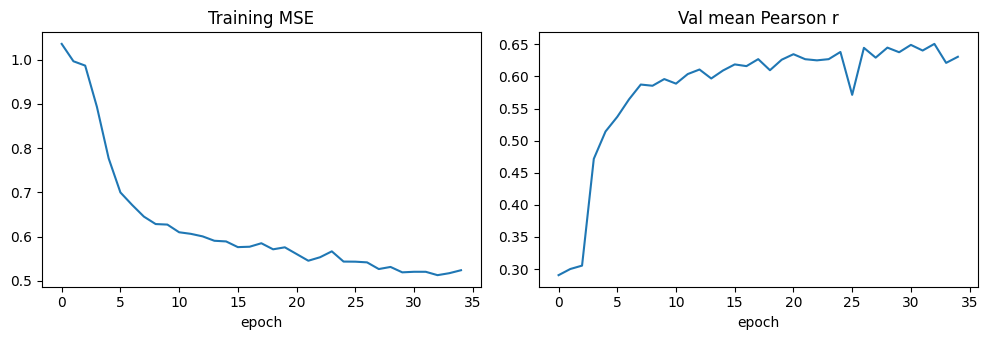

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3.5))
ax[0].plot(hist["loss"]); ax[0].set_title("Training MSE"); ax[0].set_xlabel("epoch")
ax[1].plot(hist["mean_r"]); ax[1].set_title("Val mean Pearson r"); ax[1].set_xlabel("epoch")
plt.tight_layout(); plt.show()

## 6. Evaluate &mdash; which genes are predictable from morphology?

Not all genes are equally predictable from an H&E image. Structural genes whose cells
have a distinct appearance (collagens in dermis, keratins in epidermis) tend to score
high; sparser markers (e.g. immune `PTPRC`) are harder.

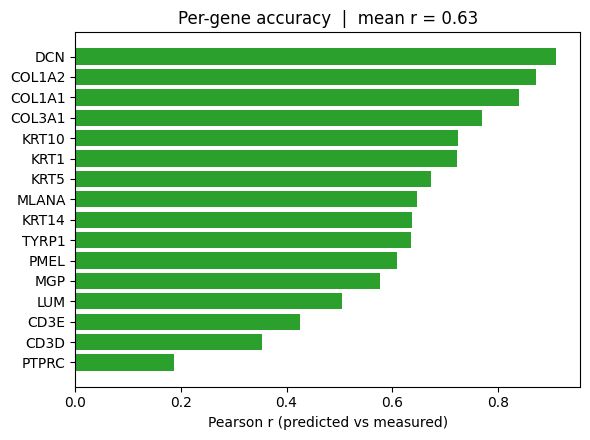

In [10]:
model.eval()
with torch.no_grad():
    pred = model(Xt[te])[0].numpy()
rs = {present[j]: pearsonr(pred[:, j], Yz[te, j])[0] for j in range(len(present))}
order = sorted(rs, key=rs.get)
plt.figure(figsize=(6, 4.5))
plt.barh(order, [rs[g] for g in order], color="tab:green")
plt.xlabel("Pearson r (predicted vs measured)")
plt.title(f"Per-gene accuracy  |  mean r = {np.nanmean(list(rs.values())):.2f}")
plt.tight_layout(); plt.show()

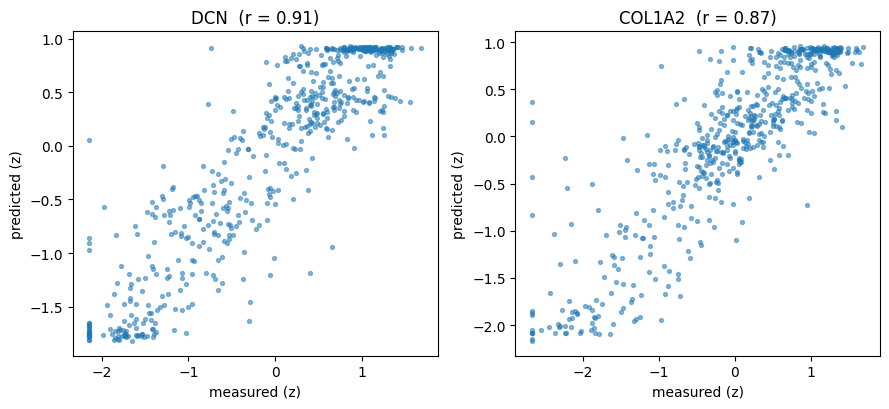

In [11]:
# Predicted vs measured (standardised) for the two best-predicted genes
best = order[::-1][:2]
fig, axes = plt.subplots(1, 2, figsize=(9, 4.2))
for ax, g in zip(axes, best):
    j = present.index(g)
    ax.scatter(Yz[te, j], pred[:, j], s=8, alpha=0.5)
    ax.set_xlabel("measured (z)"); ax.set_ylabel("predicted (z)")
    ax.set_title(f"{g}  (r = {rs[g]:.2f})")
plt.tight_layout(); plt.show()

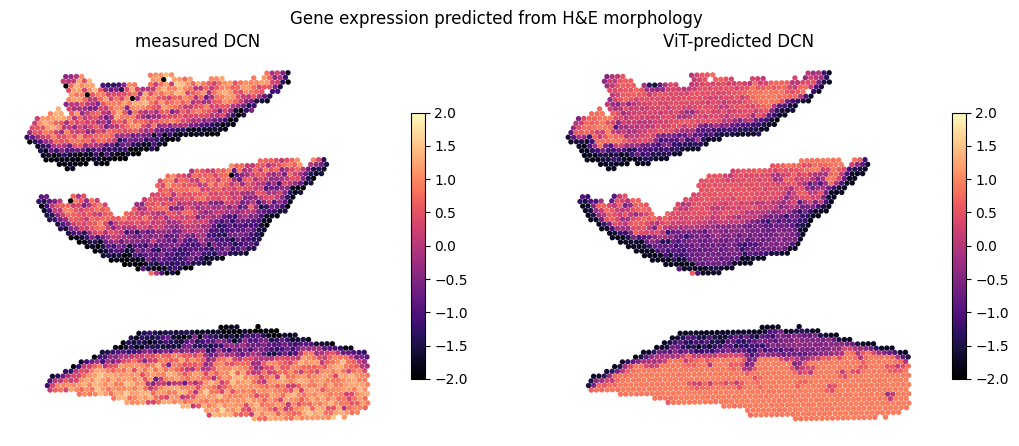

In [12]:
# Map predicted vs measured back onto the tissue for the best gene
g = order[-1]; j = present.index(g)
with torch.no_grad():
    pred_all = model(Xt)[0].numpy()
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, vals, ttl in [(axes[0], Yz[:, j], f"measured {g}"),
                      (axes[1], pred_all[:, j], f"ViT-predicted {g}")]:
    sca = ax.scatter(xy[:, 0], -xy[:, 1], c=vals, cmap="magma", s=8, vmin=-2, vmax=2)
    ax.set_aspect("equal"); ax.axis("off"); ax.set_title(ttl); plt.colorbar(sca, ax=ax, shrink=0.7)
plt.suptitle("Gene expression predicted from H&E morphology"); plt.tight_layout(); plt.show()

## 7. Where does the ViT look? (attention rollout)

We can visualise which patches the `[CLS]` token relies on using **attention rollout**
(Abnar & Zuidema, 2020): add the identity to each layer's attention (for the residual
connection), normalise, and multiply the layers together. The `[CLS]` row, reshaped to
the patch grid, shows the spatial focus on the tile.

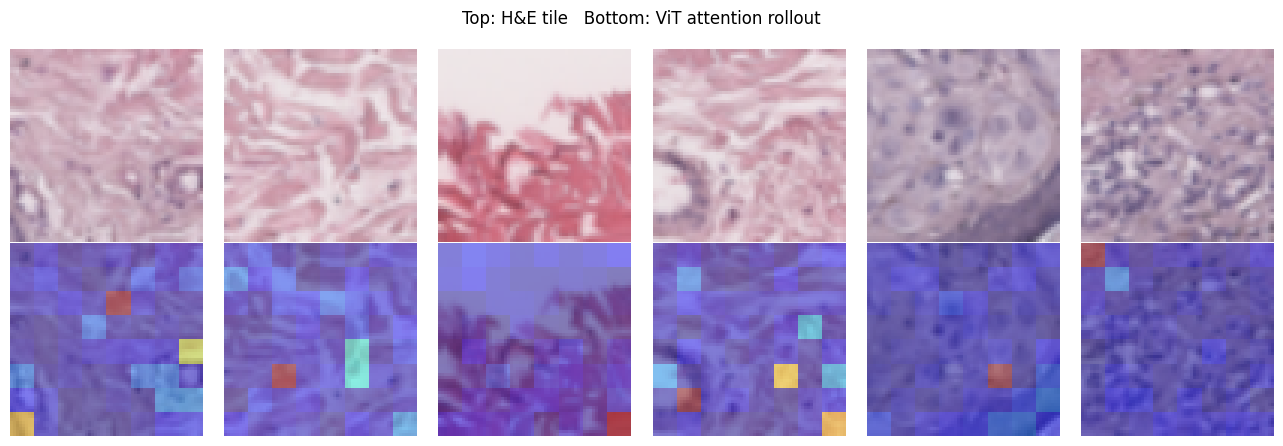

In [13]:
def attention_rollout(att_list):
    A = torch.stack(att_list, 0)               # [depth, B, seq, seq]
    eye = torch.eye(A.size(-1))
    roll = None
    for d in range(A.size(0)):
        a = A[d] + eye
        a = a / a.sum(-1, keepdim=True)
        roll = a if roll is None else torch.bmm(a, roll)
    return roll[:, 0, 1:]                       # CLS -> patches

ex = te[:6]
with torch.no_grad():
    _, attns = model(Xt[ex], need_weights=True)
maps = attention_rollout(attns).numpy()
side = int(model.n_patch ** 0.5)
import numpy as np
fig, axes = plt.subplots(2, 6, figsize=(13, 4.5))
for k, i in enumerate(ex):
    axes[0, k].imshow(tiles[i]); axes[0, k].axis("off")
    m = maps[k].reshape(side, side)
    m = np.kron(m, np.ones((tiles.shape[1] // side, tiles.shape[2] // side)))  # upscale
    axes[1, k].imshow(tiles[i]); axes[1, k].imshow(m, cmap="jet", alpha=0.45); axes[1, k].axis("off")
axes[0, 0].set_ylabel("tile", fontsize=10); axes[1, 0].set_ylabel("attention", fontsize=10)
plt.suptitle("Top: H&E tile   Bottom: ViT attention rollout"); plt.tight_layout(); plt.show()

## 8. Questions & exercises

<span style="color:blue">**Q1.**</span> We used patch size 8 (&rarr; 64 patches). Try
`patch=16` (16 patches) and `patch=4` (256 patches). How do accuracy, runtime, and the
attention maps change? What is the trade-off?

<span style="color:blue">**Q2.**</span> Remove the positional embedding (set `self.pos`
to zero). Why does performance drop, and why does it drop *less* than you might expect
for this task?

<span style="color:blue">**Q3.**</span> Which genes are easy vs hard to predict from H&E,
and does that match the biology (structural vs sparse cell types)?

<span style="color:blue">**Q4.**</span> Enlarge the crop window `WIN` so each tile sees
more tissue context around the spot. Does more context help?

<span style="color:purple">**Going further.**</span> The environment ships `timm` and
`transformers`. As an extension, replace this small ViT with a **pretrained** ViT
(e.g. `timm.create_model('vit_small_patch16_224', pretrained=True)`) and fine-tune a new
regression head &mdash; transfer learning, as in notebook 02 but with a Transformer backbone.